# Flow Matching for Physically Consistent PDE Generation

This single self-contained notebook compares **Flow Matching (FM)**, a **diffusion-path baseline**, and a **physics-regularized FM** variant on final states of the 1D viscous Burgers' equation. The aim is a fast, honest proof-of-concept: tiny dataset, tiny model, fixed seeds, and a hard cap of **50 epochs per model**.

**Research question:** do generated PDE states preserve the real data distribution of total field integral (mass), and does a lightweight mass regularizer improve FM?

## Flow Matching explained

Generative models learn to transform a simple noise distribution (for example, Gaussian noise) into a complex data distribution (for example, PDE solution states). Continuous normalizing flows do this with a continuous-time vector field that transports samples by an ODE:

```text
dx/dt = v_theta(x, t)
```

If we start at `t=0` from noise and integrate to `t=1`, the final state should look like data.

The classic CNF difficulty is training: likelihood-based CNF training usually requires solving this ODE during training, which is expensive and slow to scale.

Flow Matching uses a simulation-free trick. Instead of simulating the ODE during training, choose a closed-form conditional probability path between a noise sample `x0` and a data sample `x1`. The common Optimal Transport (OT) path is the straight line:

```text
x_t = (1 - t) * x0 + t * x1,      t in [0, 1]
```

Its target velocity is constant:

```text
u_t = x1 - x0
```

Training is then simple regression: sample `t ~ Uniform(0,1)`, sample `x0 ~ Noise`, sample `x1 ~ Data`, compute `x_t` and `u_t`, and minimize

```text
L(theta) = E[ || v_theta(x_t, t) - u_t ||^2 ]
```

No ODE solve is needed while training. At inference, we integrate `dx/dt = v_theta(x,t)` from `t=0` to `t=1`, using Euler steps, starting from noise.

Straight-line OT paths matter because diffusion models follow curved noising paths. OT can be easier to learn and can often sample well with fewer neural function evaluations (NFE).

Diffusion can be written as a special case of the same framework by using a different conditional path. Here the diffusion baseline uses a variance-preserving curved path but still trains the same vector-field network with an analytic velocity target.

The physics twist is that PDE states are not arbitrary vectors. Burgers' equation on a periodic domain approximately conserves total field integral. Straight paths from arbitrary Gaussian noise to physical data can traverse states with implausible mass. We test whether generated samples match the real mass distribution, and whether a mass-regularized FM objective helps.

In [19]:
import math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt

seed = 7
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


epochs = 50

# Small settings proof-of-concept.
n_grid = 128; n_samples = 3000; train_fraction = 0.8; batch_size = 64
learning_rate = 2e-3; hidden_channels = 48; lambda_phys = 0.1
nu = 0.01; burgers_dt = 5e-4; burgers_steps = 160
num_eval_samples = 200; sample_counts = {"fast_5_steps": 5, "accurate_50_steps": 50}

Using device: cuda


Dataset: 2400 train / 600 test, tensor shape torch.Size([3000, 1, 128])


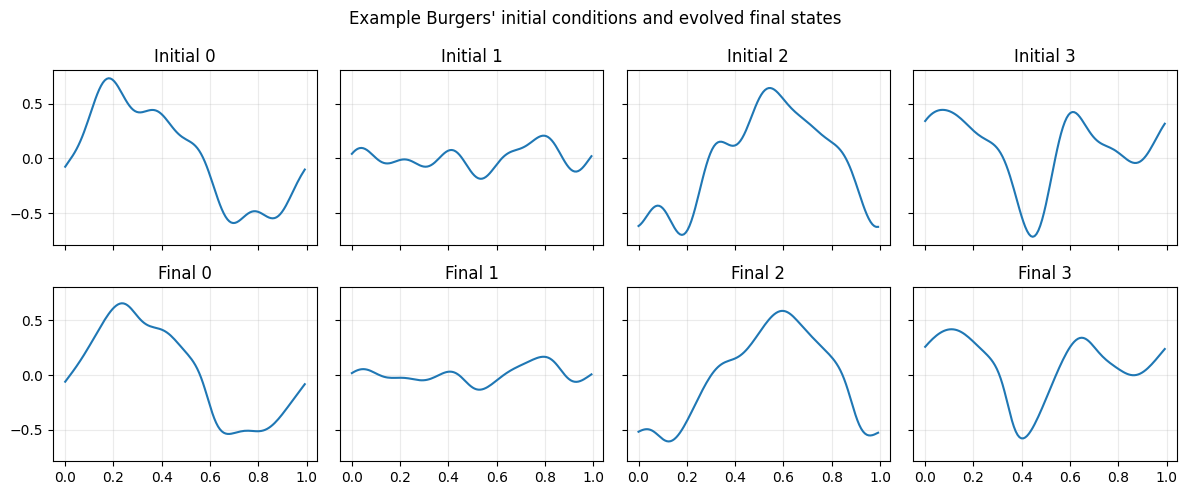

In [20]:
# Burgers' equation solver and dataset generation.
def random_smooth_initial_condition(x, max_modes=5):
    u = np.zeros_like(x)
    for k in range(1, max_modes + 1):
        u += np.random.normal(scale=0.35 / k) * np.sin(2*np.pi*k*x + np.random.uniform(0, 2*np.pi))
    return (u + np.random.normal(scale=0.05)).astype(np.float32)

def burgers_step(u, dx, dt, viscosity):
    u_r, u_l = np.roll(u, -1), np.roll(u, 1)
    u_x = (u_r - u_l) / (2 * dx)
    u_xx = (u_r - 2*u + u_l) / (dx * dx)
    return u + dt * (-u * u_x + viscosity * u_xx)

def solve_burgers(u0, steps=burgers_steps, dt=burgers_dt, viscosity=nu):
    u = u0.copy(); dx = 1.0 / len(u)
    for _ in range(steps): u = burgers_step(u, dx, dt, viscosity)
    return u.astype(np.float32)

x_grid = np.linspace(0, 1, n_grid, endpoint=False, dtype=np.float32)
initial_states = np.stack([random_smooth_initial_condition(x_grid) for _ in range(n_samples)])
final_states = np.stack([solve_burgers(u0) for u0 in initial_states])
data_mean, data_std = final_states.mean(), final_states.std() + 1e-6
final_states_std = (final_states - data_mean) / data_std

all_data = torch.tensor(final_states_std, dtype=torch.float32).unsqueeze(1)
dataset = TensorDataset(all_data)
train_size = int(train_fraction * n_samples); test_size = n_samples - train_size
gen = torch.Generator().manual_seed(seed)
train_ds, test_ds = random_split(dataset, [train_size, test_size], generator=gen)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=gen)
train_tensor = torch.stack([train_ds[i][0] for i in range(len(train_ds))])
test_tensor = torch.stack([test_ds[i][0] for i in range(len(test_ds))])
print(f"Dataset: {train_size} train / {test_size} test, tensor shape {all_data.shape}")

fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
for j in range(4):
    axes[0, j].plot(x_grid, initial_states[j]); axes[0, j].set_title(f"Initial {j}")
    axes[1, j].plot(x_grid, final_states[j]); axes[1, j].set_title(f"Final {j}")
for ax in axes.ravel(): ax.grid(alpha=0.25)
plt.suptitle("Example Burgers' initial conditions and evolved final states")
plt.tight_layout(); plt.show()

In [21]:
# Shared small 1D convolutional vector-field network.
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim=32): super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(torch.linspace(0, math.log(1000), half, device=t.device))
        args = t[:, None] * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class TinyConvVectorField(nn.Module):
    def __init__(self, hidden=hidden_channels, time_dim=32):
        super().__init__()
        self.time_embed = nn.Sequential(SinusoidalTimeEmbedding(time_dim), nn.Linear(time_dim, hidden), nn.SiLU(), nn.Linear(hidden, hidden))
        self.net = nn.Sequential(
            nn.Conv1d(1 + hidden, hidden, 5, padding=2, padding_mode="circular"), nn.SiLU(),
            nn.Conv1d(hidden, hidden, 5, padding=2, padding_mode="circular"), nn.SiLU(),
            nn.Conv1d(hidden, hidden, 3, padding=1, padding_mode="circular"), nn.SiLU(),
            nn.Conv1d(hidden, 1, 3, padding=1, padding_mode="circular"))
    def forward(self, x, t):
        emb = self.time_embed(t).unsqueeze(-1).expand(-1, -1, x.shape[-1])
        return self.net(torch.cat([x, emb], dim=1))

## Three variants

* **Baseline FM:** OT path `x_t=(1-t)x0+t*x1`, target `x1-x0`.
* **Diffusion baseline:** variance-preserving curved path `x_t=alpha(t)x1+sigma(t)x0`, with `alpha=sin(pi*t/2)` and `sigma=cos(pi*t/2)`, trained against the analytic path velocity.
* **Physics-regularized FM:** same OT path as baseline FM plus a cheap penalty on the predicted endpoint mass. From `x_t` and predicted velocity `v`, estimate `x_hat_1=x_t+(1-t)v`; penalize its spatial sum against the true `x1` spatial sum.

In [22]:
def ot_path(x1):
    x0 = torch.randn_like(x1); t = torch.rand(x1.shape[0], device=x1.device); tb = t[:, None, None]
    return (1-tb)*x0 + tb*x1, t, x1 - x0, x0

def diffusion_path(x1):
    x0 = torch.randn_like(x1); t = torch.rand(x1.shape[0], device=x1.device); tb = t[:, None, None]
    alpha, sigma = torch.sin(0.5*math.pi*tb), torch.cos(0.5*math.pi*tb)
    d_alpha, d_sigma = 0.5*math.pi*torch.cos(0.5*math.pi*tb), -0.5*math.pi*torch.sin(0.5*math.pi*tb)
    return alpha*x1 + sigma*x0, t, d_alpha*x1 + d_sigma*x0, x0

def train_model(name, variant):
    model = TinyConvVectorField().to(device); opt = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    losses = []
    for ep in range(1, epochs + 1):
        model.train(); total = 0.0; seen = 0
        for (x1,) in train_loader:
            x1 = x1.to(device)
            xt, t, target, _ = diffusion_path(x1) if variant == "diffusion" else ot_path(x1)
            pred = model(xt, t); loss = F.mse_loss(pred, target)
            if variant == "physics_fm":
                x1_hat = xt + (1 - t[:, None, None]) * pred
                mass_loss = F.mse_loss(x1_hat.sum(dim=-1), x1.sum(dim=-1)) / n_grid
                loss = loss + lambda_phys * mass_loss
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            total += loss.item() * x1.shape[0]; seen += x1.shape[0]
        losses.append(total / seen); print(f"{name:>18s} | epoch {ep}/{epochs} | loss {losses[-1]:.4f}")
    return model, losses

def plot_losses(loss_dict):
    plt.figure(figsize=(7,4))
    for name, vals in loss_dict.items(): plt.plot(range(1, len(vals)+1), vals, marker="o", label=name)
    plt.xlabel("Epoch"); plt.ylabel("Training loss"); plt.title("Loss curves"); plt.grid(alpha=0.25); plt.legend(); plt.show()

       Baseline FM | epoch 1/50 | loss 1.4999
       Baseline FM | epoch 2/50 | loss 0.7549
       Baseline FM | epoch 3/50 | loss 0.6305
       Baseline FM | epoch 4/50 | loss 0.5792
       Baseline FM | epoch 5/50 | loss 0.5471
       Baseline FM | epoch 6/50 | loss 0.5534
       Baseline FM | epoch 7/50 | loss 0.5318
       Baseline FM | epoch 8/50 | loss 0.5388
       Baseline FM | epoch 9/50 | loss 0.5389
       Baseline FM | epoch 10/50 | loss 0.5152
       Baseline FM | epoch 11/50 | loss 0.5213
       Baseline FM | epoch 12/50 | loss 0.5223
       Baseline FM | epoch 13/50 | loss 0.5263
       Baseline FM | epoch 14/50 | loss 0.5016
       Baseline FM | epoch 15/50 | loss 0.5010
       Baseline FM | epoch 16/50 | loss 0.4925
       Baseline FM | epoch 17/50 | loss 0.5240
       Baseline FM | epoch 18/50 | loss 0.5072
       Baseline FM | epoch 19/50 | loss 0.5029
       Baseline FM | epoch 20/50 | loss 0.5062
       Baseline FM | epoch 21/50 | loss 0.5064
       Baseline FM | e

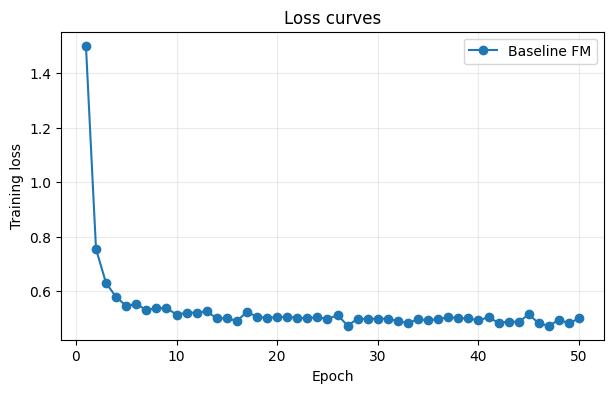

In [23]:
fm_model, fm_losses = train_model("Baseline FM", "fm")
plot_losses({"Baseline FM": fm_losses})

         Diffusion | epoch 1/50 | loss 2.0659
         Diffusion | epoch 2/50 | loss 1.5086
         Diffusion | epoch 3/50 | loss 1.0864
         Diffusion | epoch 4/50 | loss 0.8879
         Diffusion | epoch 5/50 | loss 0.8634
         Diffusion | epoch 6/50 | loss 0.8392
         Diffusion | epoch 7/50 | loss 0.8460
         Diffusion | epoch 8/50 | loss 0.7777
         Diffusion | epoch 9/50 | loss 0.8293
         Diffusion | epoch 10/50 | loss 0.8292
         Diffusion | epoch 11/50 | loss 0.8103
         Diffusion | epoch 12/50 | loss 0.7590
         Diffusion | epoch 13/50 | loss 0.8150
         Diffusion | epoch 14/50 | loss 0.7971
         Diffusion | epoch 15/50 | loss 0.8173
         Diffusion | epoch 16/50 | loss 0.7749
         Diffusion | epoch 17/50 | loss 0.7967
         Diffusion | epoch 18/50 | loss 0.7662
         Diffusion | epoch 19/50 | loss 0.7721
         Diffusion | epoch 20/50 | loss 0.7856
         Diffusion | epoch 21/50 | loss 0.7724
         Diffusion | e

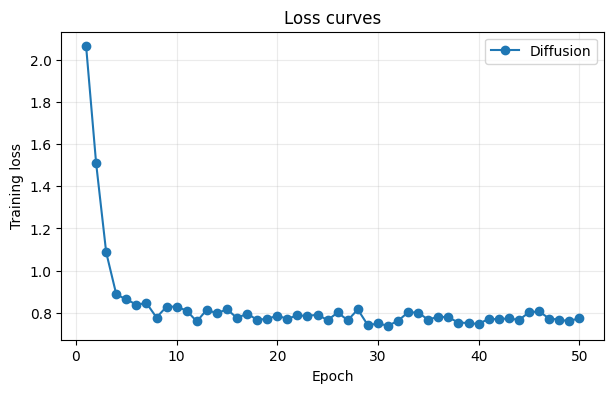

In [24]:
diff_model, diff_losses = train_model("Diffusion", "diffusion")
plot_losses({"Diffusion": diff_losses})

        Physics FM | epoch 1/50 | loss 1.6633
        Physics FM | epoch 2/50 | loss 0.9600
        Physics FM | epoch 3/50 | loss 0.8233
        Physics FM | epoch 4/50 | loss 0.7786
        Physics FM | epoch 5/50 | loss 0.7603
        Physics FM | epoch 6/50 | loss 0.7097
        Physics FM | epoch 7/50 | loss 0.7523
        Physics FM | epoch 8/50 | loss 0.7094
        Physics FM | epoch 9/50 | loss 0.7201
        Physics FM | epoch 10/50 | loss 0.6992
        Physics FM | epoch 11/50 | loss 0.6994
        Physics FM | epoch 12/50 | loss 0.6805
        Physics FM | epoch 13/50 | loss 0.6615
        Physics FM | epoch 14/50 | loss 0.6886
        Physics FM | epoch 15/50 | loss 0.6901
        Physics FM | epoch 16/50 | loss 0.6708
        Physics FM | epoch 17/50 | loss 0.7017
        Physics FM | epoch 18/50 | loss 0.6844
        Physics FM | epoch 19/50 | loss 0.6902
        Physics FM | epoch 20/50 | loss 0.6687
        Physics FM | epoch 21/50 | loss 0.6806
        Physics FM | e

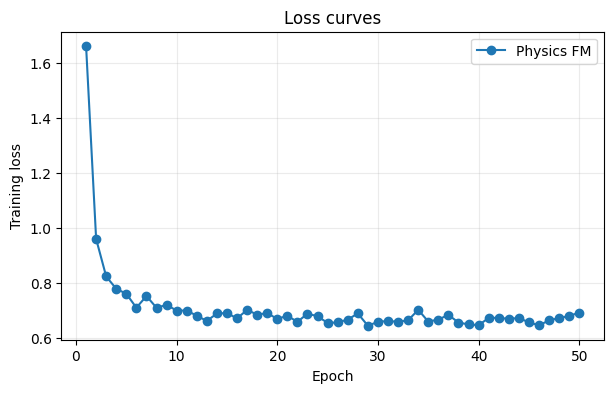

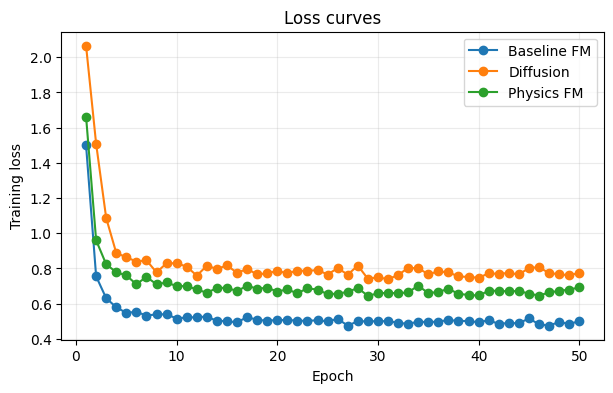

In [25]:
phys_model, phys_losses = train_model("Physics FM", "physics_fm")
plot_losses({"Physics FM": phys_losses})
plot_losses({"Baseline FM": fm_losses, "Diffusion": diff_losses, "Physics FM": phys_losses})

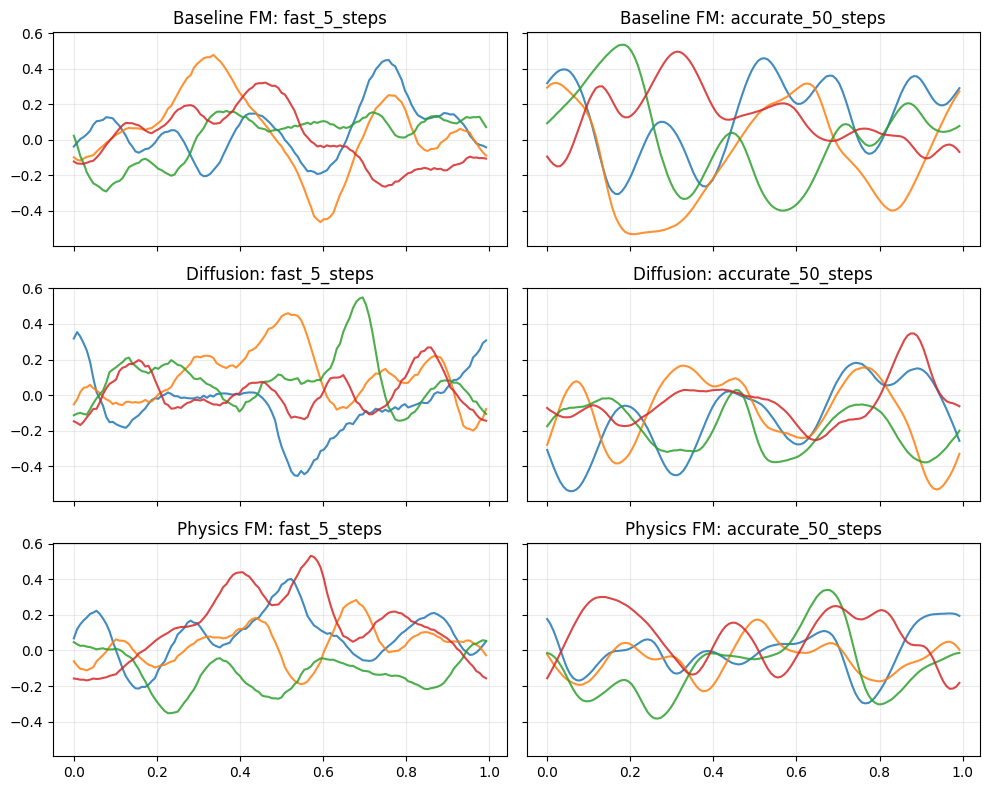

In [26]:
# Euler sampling from t=0 noise to t=1 generated samples.
@torch.no_grad()
def euler_sample(model, n, steps):
    model.eval(); x = torch.randn(n, 1, n_grid, device=device); dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((n,), i / steps, device=device)
        x = x + dt * model(x, t)
    return x.cpu()

models = {"Baseline FM": fm_model, "Diffusion": diff_model, "Physics FM": phys_model}
samples = {name: {label: euler_sample(model, num_eval_samples, steps) for label, steps in sample_counts.items()} for name, model in models.items()}

fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True, sharey=True)
for r, name in enumerate(models):
    for cidx, label in enumerate(sample_counts):
        ax = axes[r, cidx]
        for k in range(4): ax.plot(x_grid, samples[name][label][k, 0].numpy() * data_std + data_mean, alpha=0.85)
        ax.set_title(f"{name}: {label}"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

,model,steps/NFE,nearest_real_mse,mean_var_error,mass_abs_dev_from_train_mean
0,Baseline FM,5,0.170894,0.324761,0.054438
1,Baseline FM,50,0.280436,0.089439,0.072241
2,Diffusion,5,0.186135,0.322046,0.049603
3,Diffusion,50,0.246769,0.133991,0.080964
4,Physics FM,5,0.146095,0.422766,0.051336
5,Physics FM,50,0.190420,0.293487,0.057727


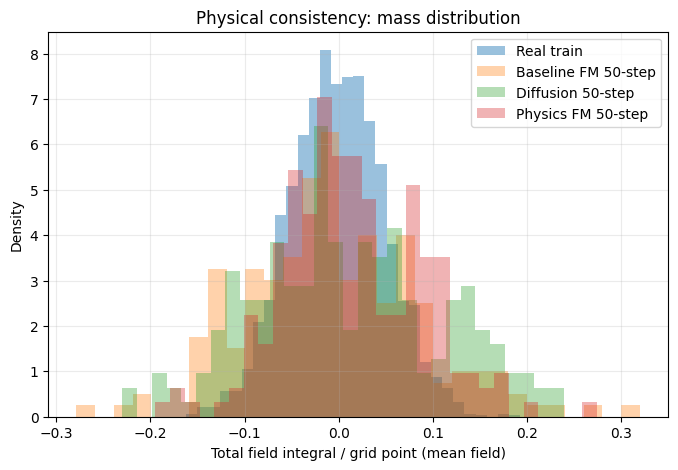

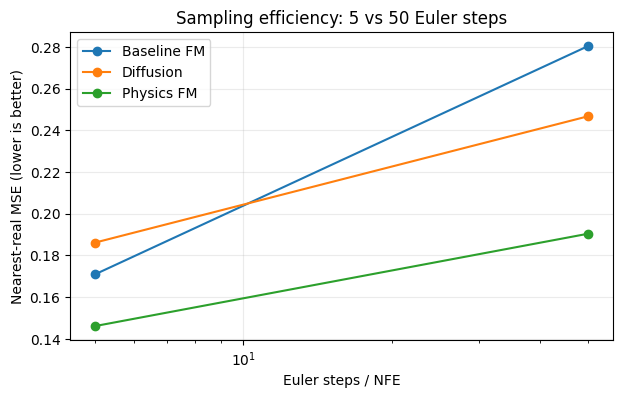

In [27]:
# Evaluation: simple quality, NFE tradeoff, and physical consistency.
def unstandardize(x): return x * data_std + data_mean

def nearest_real_mse(gen_samples, real_samples):
    g = gen_samples.flatten(1); r = real_samples.flatten(1)
    d = torch.cdist(g, r).pow(2) / n_grid
    return d.min(dim=1).values.mean().item()

def mean_var_error(gen_samples, real_samples):
    gm, gv = gen_samples.mean(dim=0), gen_samples.var(dim=0)
    rm, rv = real_samples.mean(dim=0), real_samples.var(dim=0)
    return (F.mse_loss(gm, rm) + F.mse_loss(gv, rv)).item()

def mass_values(x_std): return unstandardize(x_std).sum(dim=-1).squeeze(1).numpy() / n_grid

real_test = test_tensor.cpu(); real_train = train_tensor.cpu()
rows = []
for name in models:
    for label, steps in sample_counts.items():
        gen_s = samples[name][label]
        rows.append({
            "model": name, "steps/NFE": steps,
            "nearest_real_mse": nearest_real_mse(gen_s, real_test),
            "mean_var_error": mean_var_error(gen_s, real_test),
            "mass_abs_dev_from_train_mean": float(np.mean(np.abs(mass_values(gen_s) - mass_values(real_train).mean())))
        })

try:
    import pandas as pd
    results = pd.DataFrame(rows)
    display(results)
except Exception:
    results = rows
    for row in rows: print(row)

plt.figure(figsize=(8, 5))
plt.hist(mass_values(real_train), bins=30, alpha=0.45, density=True, label="Real train")
for name in models:
    plt.hist(mass_values(samples[name]["accurate_50_steps"]), bins=30, alpha=0.35, density=True, label=f"{name} 50-step")
plt.xlabel("Total field integral / grid point (mean field)"); plt.ylabel("Density")
plt.title("Physical consistency: mass distribution")
plt.grid(alpha=0.25); plt.legend(); plt.show()

plt.figure(figsize=(7, 4))
for name in models:
    xs = [sample_counts[label] for label in sample_counts]
    ys = [r["nearest_real_mse"] for r in rows if r["model"] == name]
    plt.plot(xs, ys, marker="o", label=name)
plt.xscale("log"); plt.xlabel("Euler steps / NFE"); plt.ylabel("Nearest-real MSE (lower is better)")
plt.title("Sampling efficiency: 5 vs 50 Euler steps")
plt.grid(alpha=0.25); plt.legend(); plt.show()